# Sandbox Simulation: Actual vs Calculated Volume Change

We simulate a toy excavator scooping sand from an 860 mm × 860 mm sandbox over 20 timesteps. The LiDAR's elevation reading at each cell is noisy (±30 mm). The goal is to check whether differencing two noisy elevation maps can recover the volume that was actually removed.

We track two arrays, both shape `(21, 50, 50)` — 21 timesteps (t=0 baseline + 20 scoops) × 50×50 grid:

- `elev_true` — true elevation, no noise. Used as ground truth.
- `elev_meas` — same scene plus Gaussian sensor noise. This is what a real LiDAR sees.

We assume at each timestep one scoop is taken: a 5×5-cell patch (~86 mm wide) drops by ~40 mm. Each scoop drifts slightly so the dig is roughly contiguous but not in one spot.

The notebook produces two outputs:

1. Volume removed over time, actual vs calculated, both per-step and cumulative.
2. A side-by-side animated heatmap of cumulative dig depth: actual on the left, calculated from noisy data on the right.

Each output reports accuracy metrics. The final section compares against deliberately bad baselines (zero, white noise) to confirm the evaluation rejects garbage outputs.

## 1. Setup

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.ndimage import gaussian_filter
from IPython.display import HTML

GRID_N             = 50
SANDBOX_MM         = 860.0
CELL_MM            = SANDBOX_MM / GRID_N            # 17.2 mm
CELL_AREA_MM2      = CELL_MM ** 2
T_STEPS            = 20

SENSOR_NOISE_MM    = 30.0                           # ±30 mm 1σ
SCOOP_DEPTH_MM     = 40.0                           # depth per scoop (realistic for repeat dig)
SCOOP_DEPTH_JITTER = 4.0                            # mm, scoop-to-scoop variation
FOOTPRINT_CELLS    = 5                              # ~86 mm wide disturbance per scoop

# Diff-noise σ propagates as √2 · σ_sensor
DIFF_SIGMA_MM       = np.sqrt(2) * SENSOR_NOISE_MM  # ~42.4 mm raw
SMOOTH_SIGMA_CELLS  = 1.5                           # Gaussian smoothing reduces effective noise
DETECT_THRESHOLD_MM = SENSOR_NOISE_MM               # 30 mm — works well after smoothing

RNG = np.random.default_rng(seed=7)

print(f"Sandbox     : {SANDBOX_MM:.0f}mm × {SANDBOX_MM:.0f}mm")
print(f"Grid        : {GRID_N}×{GRID_N} cells, cell = {CELL_MM:.2f} mm")
print(f"Time steps  : {T_STEPS} (+ t=0 baseline)")
print(f"Sensor σ    : {SENSOR_NOISE_MM:.0f} mm  →  diff σ ≈ {DIFF_SIGMA_MM:.1f} mm")
print(f"Detect thr. : {DETECT_THRESHOLD_MM:.1f} mm  (= 1·σ_sensor; smoothing first)")

Sandbox     : 860mm × 860mm
Grid        : 50×50 cells, cell = 17.20 mm
Time steps  : 20 (+ t=0 baseline)
Sensor σ    : 30 mm  →  diff σ ≈ 42.4 mm
Detect thr. : 30.0 mm  (= 1·σ_sensor; smoothing first)


## 2. Simulate ground truth and measurements

We pick a fresh dig location each timestep, drifting around the sandbox center to mimic an excavator working a roughly contiguous pit. Some scoops re-dig the same area (deeper), some open new ground.

In [15]:
elev_true = np.zeros((T_STEPS + 1, GRID_N, GRID_N), dtype=float)
scoop_locations = []

cx0, cy0 = GRID_N // 2, GRID_N // 2
drift_x = drift_y = 0.0

for t in range(1, T_STEPS + 1):
    drift_x += RNG.normal(0, 1.5)
    drift_y += RNG.normal(0, 1.5)
    cx = int(np.clip(cx0 + drift_x, FOOTPRINT_CELLS, GRID_N - FOOTPRINT_CELLS - 1))
    cy = int(np.clip(cy0 + drift_y, FOOTPRINT_CELLS, GRID_N - FOOTPRINT_CELLS - 1))

    sx, sy = cx - FOOTPRINT_CELLS // 2, cy - FOOTPRINT_CELLS // 2
    ex, ey = sx + FOOTPRINT_CELLS, sy + FOOTPRINT_CELLS

    depth = max(SCOOP_DEPTH_MM + RNG.normal(0, SCOOP_DEPTH_JITTER), 5.0)

    elev_true[t] = elev_true[t - 1].copy()
    elev_true[t, sx:ex, sy:ey] -= depth
    scoop_locations.append((cx, cy, depth))

elev_meas = elev_true + RNG.normal(0.0, SENSOR_NOISE_MM, size=elev_true.shape)

print(f"elev_true shape : {elev_true.shape}  (t=0..{T_STEPS})")
print(f"elev_meas shape : {elev_meas.shape}")
print(f"Final true min  : {elev_true[-1].min():.1f} mm  (deepest cell)")
print(f"Total scoops    : {T_STEPS}")

elev_true shape : (21, 50, 50)  (t=0..20)
elev_meas shape : (21, 50, 50)
Final true min  : -232.4 mm  (deepest cell)
Total scoops    : 20


## 3. Volume change: actual vs calculated

**Actual** (no noise): per-step removed volume = `sum(elev_true[t-1] - elev_true[t]) × cell_area`.

**Calculated** (noisy): from `elev_meas`, smooth the diff, threshold to suppress noise, sum the depth × cell area where the diff exceeds the noise floor.

In [16]:
def calc_volume_change_mm3(elev_a, elev_b):
    """Calculated volume removed going from a -> b, using noisy heuristics.
    Positive return = material removed."""
    diff = elev_a - elev_b                          # positive where dug
    diff = gaussian_filter(diff, sigma=SMOOTH_SIGMA_CELLS)
    flagged = diff > DETECT_THRESHOLD_MM
    depth_est = np.where(flagged, diff, 0.0)
    return float(depth_est.sum() * CELL_AREA_MM2)


dvol_true_mm3 = np.zeros(T_STEPS)
dvol_calc_mm3 = np.zeros(T_STEPS)
cumvol_true_mm3 = np.zeros(T_STEPS)
cumvol_calc_mm3 = np.zeros(T_STEPS)

for t in range(1, T_STEPS + 1):
    dvol_true_mm3[t - 1] = float(((elev_true[t - 1] - elev_true[t]).sum()) * CELL_AREA_MM2)
    dvol_calc_mm3[t - 1] = calc_volume_change_mm3(elev_meas[t - 1], elev_meas[t])
    cumvol_true_mm3[t - 1] = float(((elev_true[0] - elev_true[t]).sum()) * CELL_AREA_MM2)
    cumvol_calc_mm3[t - 1] = calc_volume_change_mm3(elev_meas[0], elev_meas[t])

ML_PER_MM3 = 1e-3   # 1 mm³ = 1e-3 mL = 1e-3 cm³
print(f"Final cumulative true vol  = {cumvol_true_mm3[-1]:>10.0f} mm³ "
      f"({cumvol_true_mm3[-1]*ML_PER_MM3:.2f} mL)")
print(f"Final cumulative calc vol  = {cumvol_calc_mm3[-1]:>10.0f} mm³ "
      f"({cumvol_calc_mm3[-1]*ML_PER_MM3:.2f} mL)")

Final cumulative true vol  =    5736550 mm³ (5736.55 mL)
Final cumulative calc vol  =    4954620 mm³ (4954.62 mL)


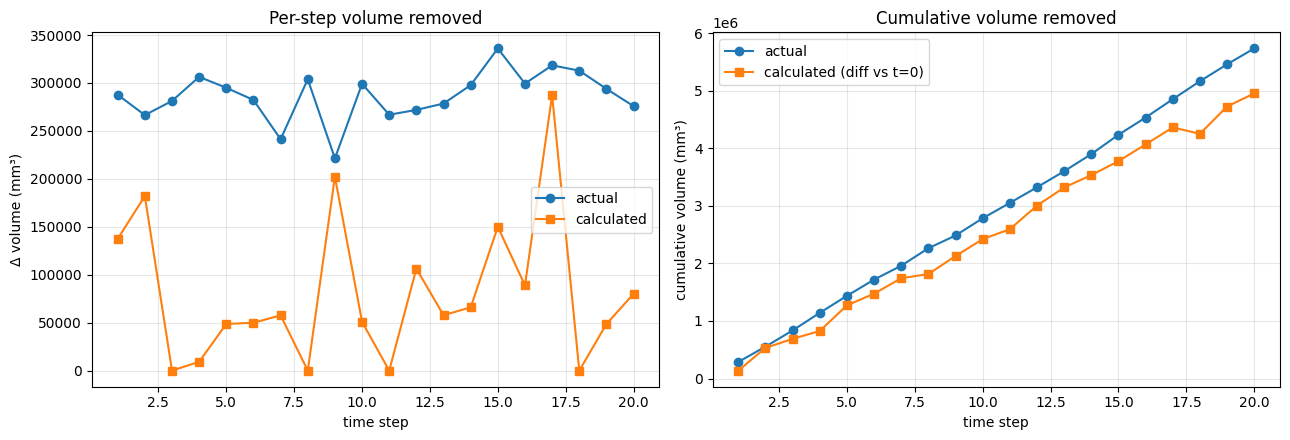

In [20]:
t_axis = np.arange(1, T_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(t_axis, dvol_true_mm3, marker='o', label='actual', color='tab:blue')
axes[0].plot(t_axis, dvol_calc_mm3, marker='s', label='calculated', color='tab:orange')
axes[0].set_xlabel('time step'); axes[0].set_ylabel('Δ volume (mm³)')
axes[0].set_title('Per-step volume removed')
axes[0].grid(alpha=0.3); axes[0].legend()

cumvol_calc_sum_mm3 = np.cumsum(dvol_calc_mm3)

axes[1].plot(t_axis, cumvol_true_mm3,     marker='o', label='actual',                         color='tab:blue')
axes[1].plot(t_axis, cumvol_calc_mm3,     marker='s', label='calculated (diff vs t=0)',       color='tab:orange')

axes[1].set_xlabel('time step'); axes[1].set_ylabel('cumulative volume (mm³)')
axes[1].set_title('Cumulative volume removed')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

The above graph shows that with a deeper scoop the value is closer to the actual volume excavated.

### 3a. Time-series accuracy metrics

In [ ]:
def safe_pct(num, den):
    return float(num / den * 100.0) if den != 0 else float('nan')


def time_series_metrics(true_arr, calc_arr, label):
    err  = calc_arr - true_arr
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    if true_arr.std() > 0 and calc_arr.std() > 0:
        corr = float(np.corrcoef(true_arr, calc_arr)[0, 1])
    else:
        corr = float('nan')
    pct_err_total = safe_pct(calc_arr.sum() - true_arr.sum(), true_arr.sum())
    return {
        'series':         label,
        'MAE_mm3':        mae,
        'RMSE_mm3':       rmse,
        'mean_bias_mm3':  bias,
        'pearson_r':      corr,
        'total_error_%':  pct_err_total,
    }


rows = [
    time_series_metrics(dvol_true_mm3,   dvol_calc_mm3,   'per-step Δ volume'),
    time_series_metrics(cumvol_true_mm3, cumvol_calc_mm3, 'cumulative volume'),
]
for r in rows:
    print(f"{r['series']:>20} | MAE = {r['MAE_mm3']:>10.0f} mm³ | "
          f"RMSE = {r['RMSE_mm3']:>10.0f} mm³ | "
          f"bias = {r['mean_bias_mm3']:>+10.0f} mm³ | "
          f"r = {r['pearson_r']:>5.2f} | "
          f"total err = {r['total_error_%']:>+6.1f}%")

## 4. Animated heatmap: actual vs calculated dig depth

Each frame `t = 1..20` shows the **cumulative** dig depth (mm) up to that timestep.  
Left = actual (`elev_true[0] - elev_true[t]`), right = calculated (smoothed + thresholded measurement diff).

In [21]:
depth_actual = np.zeros((T_STEPS, GRID_N, GRID_N))
depth_calc   = np.zeros((T_STEPS, GRID_N, GRID_N))

for t in range(1, T_STEPS + 1):
    depth_actual[t - 1] = elev_true[0] - elev_true[t]
    diff               = gaussian_filter(elev_meas[0] - elev_meas[t],
                                          sigma=SMOOTH_SIGMA_CELLS)
    depth_calc[t - 1]  = np.where(diff > DETECT_THRESHOLD_MM, diff, 0.0)

vmax = float(max(depth_actual.max(), depth_calc.max())) or 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
im0 = axes[0].imshow(depth_actual[0], origin='lower', cmap='hot_r', vmin=0, vmax=vmax)
im1 = axes[1].imshow(depth_calc[0],   origin='lower', cmap='hot_r', vmin=0, vmax=vmax)
axes[0].set_title('actual dig depth (mm)')
axes[1].set_title('calculated dig depth (mm)')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
title = fig.suptitle('t = 1')

def update(frame):
    im0.set_data(depth_actual[frame])
    im1.set_data(depth_calc[frame])
    title.set_text(f't = {frame + 1} / {T_STEPS}')
    return [im0, im1, title]

ani = animation.FuncAnimation(
    fig, update, frames=T_STEPS, interval=350, blit=False, repeat=True,
)
plt.close(fig)
HTML(ani.to_jshtml())

### 4a. Heatmap accuracy metrics

Two complementary views:
- **Per-cell error**: how close calculated depth is to actual depth (mm), averaged over cells, per frame.
- **Spatial overlap (IoU)**: how well the calculated dig footprint matches the actual one, per frame. We scale it to 5 mm: a cell counts as dug if cumulative depth > 5 mm.

In [22]:
DUG_THRESHOLD_MM = 5.0

per_frame = []
for t in range(T_STEPS):
    err = depth_calc[t] - depth_actual[t]
    mae_cell  = float(np.mean(np.abs(err)))
    rmse_cell = float(np.sqrt(np.mean(err ** 2)))

    gt_mask   = depth_actual[t] > DUG_THRESHOLD_MM
    pred_mask = depth_calc[t]   > DUG_THRESHOLD_MM
    inter = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask,  pred_mask).sum()
    iou   = float(inter / union) if union > 0 else (1.0 if not pred_mask.any() else 0.0)

    per_frame.append({
        'frame':    t + 1,
        'MAE_mm':   mae_cell,
        'RMSE_mm':  rmse_cell,
        'IoU':      iou,
        'gt_cells': int(gt_mask.sum()),
        'pred_cells': int(pred_mask.sum()),
    })

mae_arr  = np.array([r['MAE_mm']  for r in per_frame])
rmse_arr = np.array([r['RMSE_mm'] for r in per_frame])
iou_arr  = np.array([r['IoU']     for r in per_frame])

print(f"Heatmap — per-cell MAE  (avg across {T_STEPS} frames): {mae_arr.mean():.2f} mm "
      f"(min {mae_arr.min():.2f}, max {mae_arr.max():.2f})")
print(f"Heatmap — per-cell RMSE (avg across {T_STEPS} frames): {rmse_arr.mean():.2f} mm "
      f"(min {rmse_arr.min():.2f}, max {rmse_arr.max():.2f})")
print(f"Heatmap — IoU @ 5 mm    (avg across {T_STEPS} frames): {iou_arr.mean():.3f} "
      f"(min {iou_arr.min():.3f}, max {iou_arr.max():.3f})")
print(f"Heatmap — final-frame IoU @ 5 mm                    : {iou_arr[-1]:.3f}")

Heatmap — per-cell MAE  (avg across 20 frames): 1.43 mm (min 0.21, max 2.66)
Heatmap — per-cell RMSE (avg across 20 frames): 7.50 mm (min 2.66, max 11.13)
Heatmap — IoU @ 5 mm    (avg across 20 frames): 0.797 (min 0.520, max 0.873)
Heatmap — final-frame IoU @ 5 mm                    : 0.850


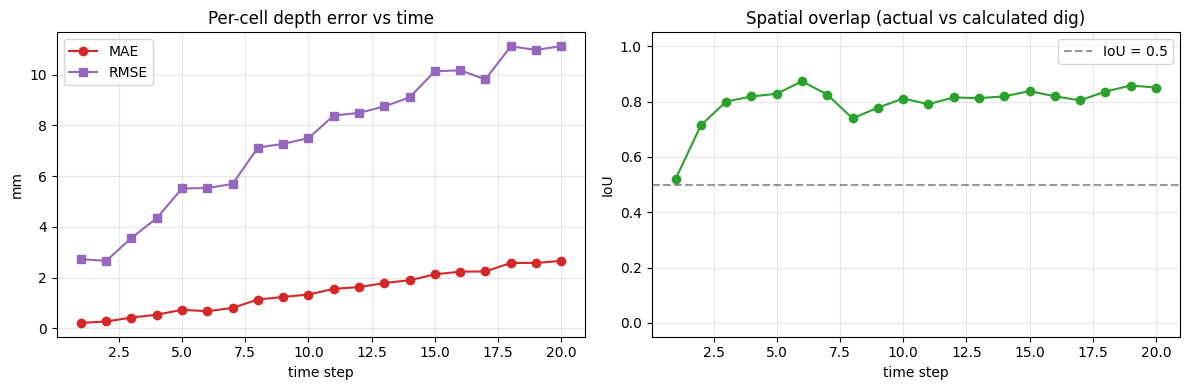

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_axis, mae_arr,  marker='o', label='MAE',  color='tab:red')
axes[0].plot(t_axis, rmse_arr, marker='s', label='RMSE', color='tab:purple')
axes[0].set_xlabel('time step'); axes[0].set_ylabel('mm')
axes[0].set_title('Per-cell depth error vs time')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(t_axis, iou_arr, marker='o', color='tab:green')
axes[1].axhline(0.5, color='k', linestyle='--', alpha=0.4, label='IoU = 0.5')
axes[1].set_xlabel('time step'); axes[1].set_ylabel('IoU')
axes[1].set_title('Spatial overlap (actual vs calculated dig)')
axes[1].set_ylim(-0.05, 1.05); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

## 5. Obviously bad outputs must fail

We compare our pipeline against three deliberately bad predictors using the same metrics:

- Zero baseline: always predicts no excavation.
- White-noise baseline: independent Gaussian values pretending to be cumulative volume.
- Random spatial map: uniform random depth on the final-frame grid.

Pass threshold:

- Cumulative volume RMSE: ours < zero, and ours < white-noise.
- Cumulative volume correlation: ours r > 0.5, white-noise |r| < 0.35.
- Final-frame spatial IoU at 5 mm: ours > random map, and ours > zero map.

If all three pass, the evaluation rejects the bad outputs.

In [24]:
def _rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


def _pearson(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


def _iou_binary(pred_mask, gt_mask):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    if union == 0:
        return 1.0
    return float(inter / union)


# --- Bad baselines (same arrays / timestep structure as the real pipeline) ---
cum_zero = np.zeros(T_STEPS)

rng_bad = np.random.default_rng(seed=12345)
# IMPORTANT: do NOT build the "random" baseline as independent junk values at each timestep (like predicting cumulative volume from noise).
cum_random_volume = rng_bad.normal(
    loc=float(cumvol_true_mm3.mean()),
    scale=float(max(cumvol_true_mm3.std(), 1.0)),
    size=T_STEPS,
)

# Final-frame spatial baselines (need actual cumulative depth from simulation)
final_actual = elev_true[0] - elev_true[T_STEPS]
gt_mask_final = final_actual > DUG_THRESHOLD_MM

pred_mask_ours = depth_calc[T_STEPS - 1] > DUG_THRESHOLD_MM
depth_random_map = rng_bad.uniform(
    0.0, float(max(final_actual.max(), 1.0)), size=final_actual.shape
)
pred_mask_random_spatial = depth_random_map > DUG_THRESHOLD_MM
pred_mask_zero_spatial = np.zeros_like(gt_mask_final, dtype=bool)

vol_rows = []
for label, cum_pred in [
    ("Our calculated pipeline", cumvol_calc_mm3),
    ("BAD: zero-change (always 0)", cum_zero),
    ("BAD: white-noise cumulative prediction", cum_random_volume),
]:
    vol_rows.append({
        "method": label,
        "RMSE_vs_actual_mm3": _rmse(cumvol_true_mm3, cum_pred),
        "Pearson_r": _pearson(cumvol_true_mm3, cum_pred),
    })

vol_df_text = "\n".join(
    f"  {r['method']:<38}  RMSE={r['RMSE_vs_actual_mm3']:>12.0f}   r={r['Pearson_r']:>6.3f}"
    for r in vol_rows
)
print("Cumulative volume — same ground truth, different predictors:\n")
print(vol_df_text)

iou_ours = _iou_binary(pred_mask_ours, gt_mask_final)
iou_zero = _iou_binary(pred_mask_zero_spatial, gt_mask_final)
iou_rand = _iou_binary(pred_mask_random_spatial, gt_mask_final)

print(
    f"\nFinal-frame spatial IoU (mask = depth > {DUG_THRESHOLD_MM} mm):\n"
    f"  Our calculated map              IoU = {iou_ours:.3f}\n"
    f"  BAD: all-zero depth map         IoU = {iou_zero:.3f}\n"
    f"  BAD: uniform random depth map   IoU = {iou_rand:.3f}\n"
)

# Checks pass / fail 
ours = vol_rows[0]
bad0 = vol_rows[1]
badR = vol_rows[2]

pass_vol_rmse = (
    ours["RMSE_vs_actual_mm3"] < bad0["RMSE_vs_actual_mm3"]
    and ours["RMSE_vs_actual_mm3"] < badR["RMSE_vs_actual_mm3"]
)
pr = ours["Pearson_r"]
pass_vol_r = (
    pr is not None and not np.isnan(pr) and pr > 0.5
    and (np.isnan(badR["Pearson_r"]) or abs(badR["Pearson_r"]) < 0.35)
)
pass_iou = iou_ours > iou_rand and iou_ours > iou_zero

all_pass = pass_vol_rmse and pass_vol_r and pass_iou

print("Checks:")
print(f"  [ {'PASS' if pass_vol_rmse else 'FAIL'} ] Pipeline RMSE beats zero & random volume")
print(f"  [ {'PASS' if pass_vol_r else 'FAIL'} ] Pipeline r > 0.5  AND  |r_white_noise| < 0.35")
print(f"  [ {'PASS' if pass_iou else 'FAIL'} ] Pipeline IoU > random map AND > empty map")
print()
n_passed = int(pass_vol_rmse) + int(pass_vol_r) + int(pass_iou)
print(f"\nOverall: {n_passed}/3 checks passed")
if all_pass:
    print("PASS — pipeline beats all bad baselines on every metric.")
else:
    print("FAIL — at least one check did not pass; pipeline is not clearly distinguished from the bad baselines on this run.")

Cumulative volume — same ground truth, different predictors:

  Our calculated pipeline                 RMSE=      442320   r= 0.997
  BAD: zero-change (always 0)             RMSE=     3393883   r=   nan
  BAD: white-noise cumulative prediction  RMSE=     2093442   r= 0.264

Final-frame spatial IoU (mask = depth > 5.0 mm):
  Our calculated map              IoU = 0.850
  BAD: all-zero depth map         IoU = 0.000
  BAD: uniform random depth map   IoU = 0.077

Checks:
  [ PASS ] Pipeline RMSE beats zero & random volume
  [ PASS ] Pipeline r > 0.5  AND  |r_white_noise| < 0.35
  [ PASS ] Pipeline IoU > random map AND > empty map


Overall: 3/3 checks passed
PASS — pipeline beats all bad baselines on every metric.
